# Part B - Text Vectorization and Spam Classification

**Dataset:** 5172 emails, one per row. Columns: `Email No.` (anonymised name), 3000 word-count columns (the 3000 most common words, alphabetic only), and `Prediction` (1 = spam, 0 = not spam).

**Approach:** the file is already a bag-of-words count matrix, so there is no raw text to vectorize. To still follow the task (*text -> CountVectorizer / TF-IDF Vectorizer*), we:
1. Rebuild a pseudo-text for every email by repeating each word as many times as its count. Word order is lost, but bag-of-words vectorizers never use order.
2. Verify that `CountVectorizer` on that text reproduces the original counts exactly.
3. Run genuine `CountVectorizer` and `TfidfVectorizer` on the text, train classifiers on both, and compare performance, features, training time and prediction time.

## 1. Imports and configuration

In [4]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.width", 200, "display.max_columns", 30)

# ---- CONFIG ----
DATA_PATH = "..\emails_data\emails.csv"        # path to your CSV
ID_COL = "Email No."
LABEL_COL = "Prediction"
RANDOM_STATE = 42
N_REPEATS = 5                   # timing repeats for stable averages
DROP_DUPLICATES = True          # drop identical email rows (same counts and label)
TOKEN_PATTERN = r"(?u)\b\w+\b"  # keeps 1-letter words such as 'a' (default patt|ern drops them)

## 2. Load the dataset

In [5]:
pdf = pd.read_csv(DATA_PATH)
print("Shape:", pdf.shape)
pdf.head(10)

Shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,in,on,is,this,enron,...,plain,prompt,remains,ifhsc,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,18,21,13,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,4,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,1,5,9,2,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,3,12,2,2,0,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
5,Email 6,4,5,1,4,2,3,45,1,0,16,12,8,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
6,Email 7,5,3,1,3,2,1,37,0,0,9,4,6,2,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,Email 8,0,2,2,3,1,2,21,6,0,2,6,2,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
8,Email 9,2,2,3,0,0,1,18,0,0,3,3,2,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,Email 10,4,4,35,0,1,0,49,1,16,9,4,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Inspect structure and spam / non-spam distribution

Emails: 5172 | Word columns: 3000
Missing values: 0
Count dtypes: {dtype('int64'): 3000}
            count  percent
Prediction                
non-spam     3672     71.0
spam         1500     29.0


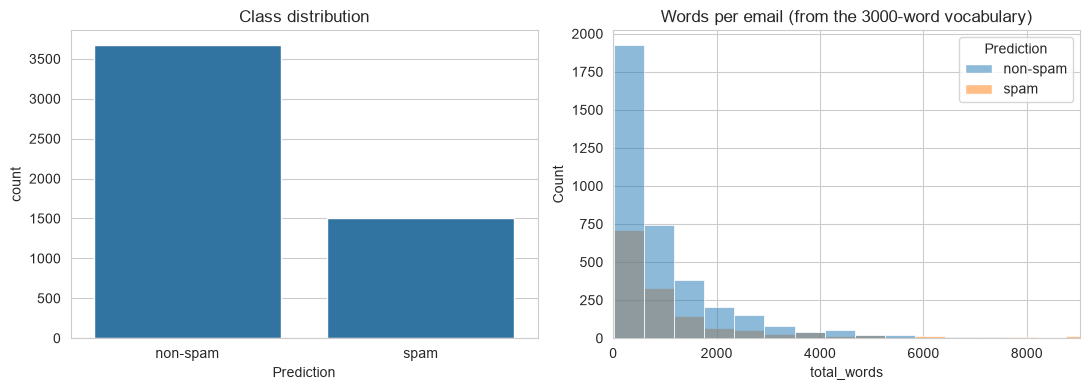

             count    mean     std   min    25%    50%     75%      max
Prediction                                                             
non-spam    3672.0  1045.4  1478.0  21.0  244.0  551.5  1293.8  27319.0
spam        1500.0  1458.8  2283.8   8.0  316.0  632.0  1506.0  29178.0


In [6]:
word_cols = [c for c in pdf.columns if c not in (ID_COL, LABEL_COL)]
print("Emails:", len(pdf), "| Word columns:", len(word_cols))
print("Missing values:", int(pdf.isna().sum().sum()))
print("Count dtypes:", pdf[word_cols].dtypes.value_counts().to_dict())

counts = pdf[LABEL_COL].value_counts().rename({0: "non-spam", 1: "spam"})
percent = (pdf[LABEL_COL].value_counts(normalize=True) * 100).round(2).rename({0: "non-spam", 1: "spam"})
print(pd.DataFrame({"count": counts, "percent": percent}))

pdf["total_words"] = pdf[word_cols].sum(axis=1)
label_names = pdf[LABEL_COL].map({0: "non-spam", 1: "spam"})

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=label_names, ax=ax[0])
ax[0].set_title("Class distribution")
sns.histplot(data=pdf, x="total_words", hue=label_names, bins=50, ax=ax[1])
ax[1].set_xlim(0, pdf["total_words"].quantile(0.99))
ax[1].set_title("Words per email (from the 3000-word vocabulary)")
plt.tight_layout()
plt.show()

print(pdf.groupby(label_names)["total_words"].describe().round(1))

**Observation:** comment on the class imbalance here. If spam is the minority class, accuracy alone can be misleading, so we focus on precision, recall and F1 for the spam class.

## 4. Basic cleaning

The words were already lowercased and stripped of non-alphabetic characters upstream, so cleaning here means validating the data:
- drop the identifier column (`Email No.` carries no signal),
- tidy the word names (lowercase, strip whitespace),
- check counts are non-negative integers,
- look at duplicate emails and emails with zero vocabulary words.

In [7]:
clean = pdf.drop(columns=["total_words"]).copy()
clean = clean.rename(columns={c: c.strip().lower() for c in word_cols})
word_cols = [c.strip().lower() for c in word_cols]

assert (clean[word_cols].values >= 0).all(), "Negative counts found"
assert clean[word_cols].apply(lambda s: (s % 1 == 0).all()).all(), "Non-integer counts found"
assert len(set(word_cols)) == len(word_cols), "Duplicate word columns after lowercasing"

n_dup = clean.drop(columns=[ID_COL]).duplicated().sum()
n_empty = int((clean[word_cols].sum(axis=1) == 0).sum())
print("Duplicate emails (identical counts + label):", n_dup)
print("Emails with zero vocabulary words:", n_empty)

if DROP_DUPLICATES:
    clean = clean.drop_duplicates(subset=word_cols + [LABEL_COL]).reset_index(drop=True)
print("Shape after cleaning:", clean.shape)
print("Class balance now:", clean[LABEL_COL].value_counts().to_dict())

Duplicate emails (identical counts + label): 541
Emails with zero vocabulary words: 0
Shape after cleaning: (4631, 3002)
Class balance now: {0: 3170, 1: 1461}


## 5. Rebuild pseudo-text from the counts

Each email becomes a string in which every word appears as many times as its count. Example: counts `{the: 2, free: 1}` -> `"the the free"`.

In [8]:
vocab = np.array(word_cols)
counts_matrix = clean[word_cols].values.astype(int)
y = clean[LABEL_COL].values

t0 = time.perf_counter()
texts = [" ".join(np.repeat(vocab, row)) for row in counts_matrix]
print(f"Rebuilt {len(texts)} emails in {time.perf_counter() - t0:.2f}s")

i = 1
print("\nTop words in email", i, "->", dict(clean.loc[i, word_cols].sort_values(ascending=False).head(5)))
print("Pseudo-text snippet:", texts[i][:200], "...")

Rebuilt 4631 emails in 2.25s

Top words in email 1 -> {'e': np.int64(141), 'o': np.int64(131), 'r': np.int64(122), 'a': np.int64(102), 's': np.int64(95)}
Pseudo-text snippet: the the the the the the the the to to to to to to to to to to to to to ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect ect and and and and and and for for f ...


### Sanity check: does CountVectorizer reproduce the original counts exactly?

In [9]:
check_cv = CountVectorizer(token_pattern=TOKEN_PATTERN)
X_check = check_cv.fit_transform(texts)

# CountVectorizer sorts its vocabulary alphabetically; align to the original column order
order = [list(check_cv.get_feature_names_out()).index(w) for w in vocab]
identical = (X_check.toarray()[:, order] == counts_matrix).all()
print("Vocabulary size recovered:", X_check.shape[1], "of", len(vocab))
print("CountVectorizer matches the original counts exactly:", identical)

Vocabulary size recovered: 3000 of 3000
CountVectorizer matches the original counts exactly: True


## 6. Train / test split
Stratified split keeps the spam ratio equal in both sets. Vectorizers are fit **only on training text** to avoid leakage (this matters especially for TF-IDF, whose IDF values are learned).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Spam % in train:", round(y_train.mean() * 100, 2), "| in test:", round(y_test.mean() * 100, 2))

Train: 3704 | Test: 927
Spam % in train: 31.56 | in test: 31.5


## 7. Define vectorizers and models

No stop-word removal is applied: stop words such as `the`, `to`, `and` are already among the 3000 columns, and removing them would change the vocabulary. Both vectorizers use identical token settings, so the only difference is the weighting scheme.

In [11]:
def make_vectorizer(name):
    if name == "CountVectorizer":
        return CountVectorizer(token_pattern=TOKEN_PATTERN)
    if name == "TF-IDF":
        return TfidfVectorizer(token_pattern=TOKEN_PATTERN, sublinear_tf=True)

def make_model(name):
    if name == "MultinomialNB":
        return MultinomialNB()
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=1000, class_weight="balanced")
    if name == "LinearSVC":
        return LinearSVC(class_weight="balanced")

vec_names = ["CountVectorizer", "TF-IDF"]
model_names = ["MultinomialNB", "LogisticRegression", "LinearSVC"]

## 8. Vectorize the text
Vectorization time is measured separately (fit + transform on train, transform on test), averaged over several runs.

In [12]:
vectorizers, features, vec_stats = {}, {}, []

for vec_name in vec_names:
    fit_times, tr_times = [], []
    for _ in range(N_REPEATS):
        vec = make_vectorizer(vec_name)
        t0 = time.perf_counter()
        Xtr = vec.fit_transform(X_train)
        fit_times.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        Xte = vec.transform(X_test)
        tr_times.append(time.perf_counter() - t0)

    vectorizers[vec_name] = vec
    features[vec_name] = (Xtr, Xte)
    vec_stats.append({
        "Vectorizer": vec_name,
        "Features": Xtr.shape[1],
        "Train matrix shape": Xtr.shape,
        "Non-zeros": Xtr.nnz,
        "Sparsity %": round(100 * (1 - Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1])), 2),
        "Fit+transform train (s)": round(np.mean(fit_times), 4),
        "Transform test (s)": round(np.mean(tr_times), 4),
        "Value range": f"{Xtr.min():.2f} to {Xtr.max():.2f}",
    })

pd.DataFrame(vec_stats)

,Vectorizer,Features,Train matrix shape,Non-zeros,Sparsity %,Fit+transform train (s),Transform test (s),Value range
0,CountVectorizer,3000,"(3704, 3000)",656646,94.09,2.3934,0.6108,0.00 to 2327.00
1,TF-IDF,3000,"(3704, 3000)",656646,94.09,2.4608,0.6147,0.00 to 0.67


### Peek at the vocabulary and weights

In [13]:
cv, tf = vectorizers["CountVectorizer"], vectorizers["TF-IDF"]
Xtr_cv, _ = features["CountVectorizer"]
Xtr_tf, _ = features["TF-IDF"]

terms = cv.get_feature_names_out()
top_cv = np.asarray(Xtr_cv.sum(axis=0)).ravel().argsort()[::-1][:15]
top_tf = np.asarray(Xtr_tf.mean(axis=0)).ravel().argsort()[::-1][:15]
print("Most frequent (count):  ", list(terms[top_cv]))
print("Highest mean TF-IDF:    ", list(tf.get_feature_names_out()[top_tf]))

# Lowest IDF = words appearing in almost every email (down-weighted by TF-IDF)
idf = pd.Series(tf.idf_, index=tf.get_feature_names_out()).sort_values()
print("\nLowest IDF (most common words):", list(idf.head(10).index))
print("Highest IDF (rarest words):    ", list(idf.tail(10).index))

Most frequent (count):   ['e', 't', 'a', 'o', 'n', 'i', 'r', 's', 'l', 'c', 'h', 'd', 'u', 'm', 'p']
Highest mean TF-IDF:     ['e', 't', 'o', 'a', 'n', 'r', 's', 'i', 'l', 'c', 'h', 'u', 'd', 'm', 'p']

Lowest IDF (most common words): ['c', 'j', 't', 'ect', 'e', 'u', 'b', 'ct', 'o', 'r']
Highest IDF (rarest words):     ['htmlimg', 'spacer', 'milwaukee', 'ftar', 'hotlist', 'hottlist', 'itoy', 'moopid', 'knle', 'abdv']


## 9. Train models on both representations and time them

In [14]:
results, conf_mats, reports = [], {}, {}

for vec_name in vec_names:
    Xtr, Xte = features[vec_name]

    for model_name in model_names:
        train_times, pred_times = [], []
        for _ in range(N_REPEATS):
            model = make_model(model_name)

            t0 = time.perf_counter()
            model.fit(Xtr, y_train)
            train_times.append(time.perf_counter() - t0)

            t0 = time.perf_counter()
            y_pred = model.predict(Xte)
            pred_times.append(time.perf_counter() - t0)

        results.append({
            "Vectorizer": vec_name,
            "Model": model_name,
            "Features": Xtr.shape[1],
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "Train time (s)": np.mean(train_times),
            "Predict time (s)": np.mean(pred_times),
        })
        conf_mats[(vec_name, model_name)] = confusion_matrix(y_test, y_pred)
        reports[(vec_name, model_name)] = classification_report(
            y_test, y_pred, target_names=["non-spam", "spam"])

res = pd.DataFrame(results)
res.round(4)

,Vectorizer,Model,Features,Accuracy,Precision,Recall,F1,Train time (s),Predict time (s)
0,CountVectorizer,MultinomialNB,3000,0.9515,0.8946,0.9589,0.9256,0.0064,0.0022
1,CountVectorizer,LogisticRegression,3000,0.9720,0.9375,0.9760,0.9564,2.0337,0.0012
2,CountVectorizer,LinearSVC,3000,0.9763,0.9530,0.9726,0.9627,2.1983,0.0015
3,TF-IDF,MultinomialNB,3000,0.9374,0.8874,0.9178,0.9024,0.0058,0.0017
4,TF-IDF,LogisticRegression,3000,0.9720,0.9209,0.9966,0.9572,0.0420,0.0009
5,TF-IDF,LinearSVC,3000,0.9838,0.9695,0.9795,0.9744,0.0719,0.0013


## 10. Comparison tables

In [15]:
res.sort_values("F1", ascending=False).round(4).reset_index(drop=True)

,Vectorizer,Model,Features,Accuracy,Precision,Recall,F1,Train time (s),Predict time (s)
0,TF-IDF,LinearSVC,3000,0.9838,0.9695,0.9795,0.9744,0.0719,0.0013
1,CountVectorizer,LinearSVC,3000,0.9763,0.9530,0.9726,0.9627,2.1983,0.0015
2,TF-IDF,LogisticRegression,3000,0.9720,0.9209,0.9966,0.9572,0.0420,0.0009
3,CountVectorizer,LogisticRegression,3000,0.9720,0.9375,0.9760,0.9564,2.0337,0.0012
4,CountVectorizer,MultinomialNB,3000,0.9515,0.8946,0.9589,0.9256,0.0064,0.0022
5,TF-IDF,MultinomialNB,3000,0.9374,0.8874,0.9178,0.9024,0.0058,0.0017


In [16]:
# Vectorizer-level summary: average over the three models
end_to_end = res.copy()
end_to_end["Total time (s)"] = end_to_end["Train time (s)"] + end_to_end["Predict time (s)"]

summary = end_to_end.groupby("Vectorizer").agg(
    Features=("Features", "first"),
    Accuracy=("Accuracy", "mean"),
    Precision=("Precision", "mean"),
    Recall=("Recall", "mean"),
    F1=("F1", "mean"),
    Train_time_s=("Train time (s)", "mean"),
    Predict_time_s=("Predict time (s)", "mean"),
).round(5)
summary

,Features,Accuracy,Precision,Recall,F1,Train_time_s,Predict_time_s
Vectorizer,,,,,,,
CountVectorizer,3000,0.96656,0.92836,0.96918,0.94824,1.41283,0.00163
TF-IDF,3000,0.96440,0.92593,0.96461,0.94468,0.03990,0.00129


## 11. Visual comparison

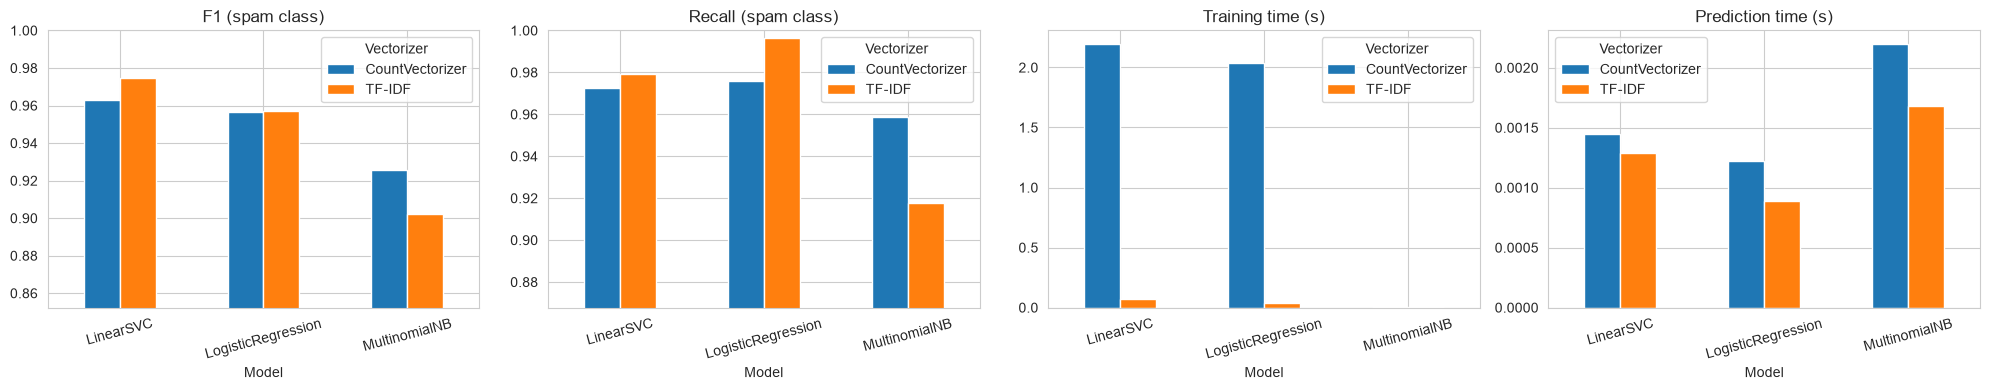

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, metric in zip(axes[:2], ["F1", "Recall"]):
    res.pivot(index="Model", columns="Vectorizer", values=metric).plot(kind="bar", ax=ax, rot=15)
    ax.set_title(metric + " (spam class)")
    ax.set_ylim(max(0, res[metric].min() - 0.05), 1.0)

res.pivot(index="Model", columns="Vectorizer", values="Train time (s)").plot(kind="bar", ax=axes[2], rot=15)
axes[2].set_title("Training time (s)")
res.pivot(index="Model", columns="Vectorizer", values="Predict time (s)").plot(kind="bar", ax=axes[3], rot=15)
axes[3].set_title("Prediction time (s)")

plt.tight_layout()
plt.show()

## 12. Confusion matrices

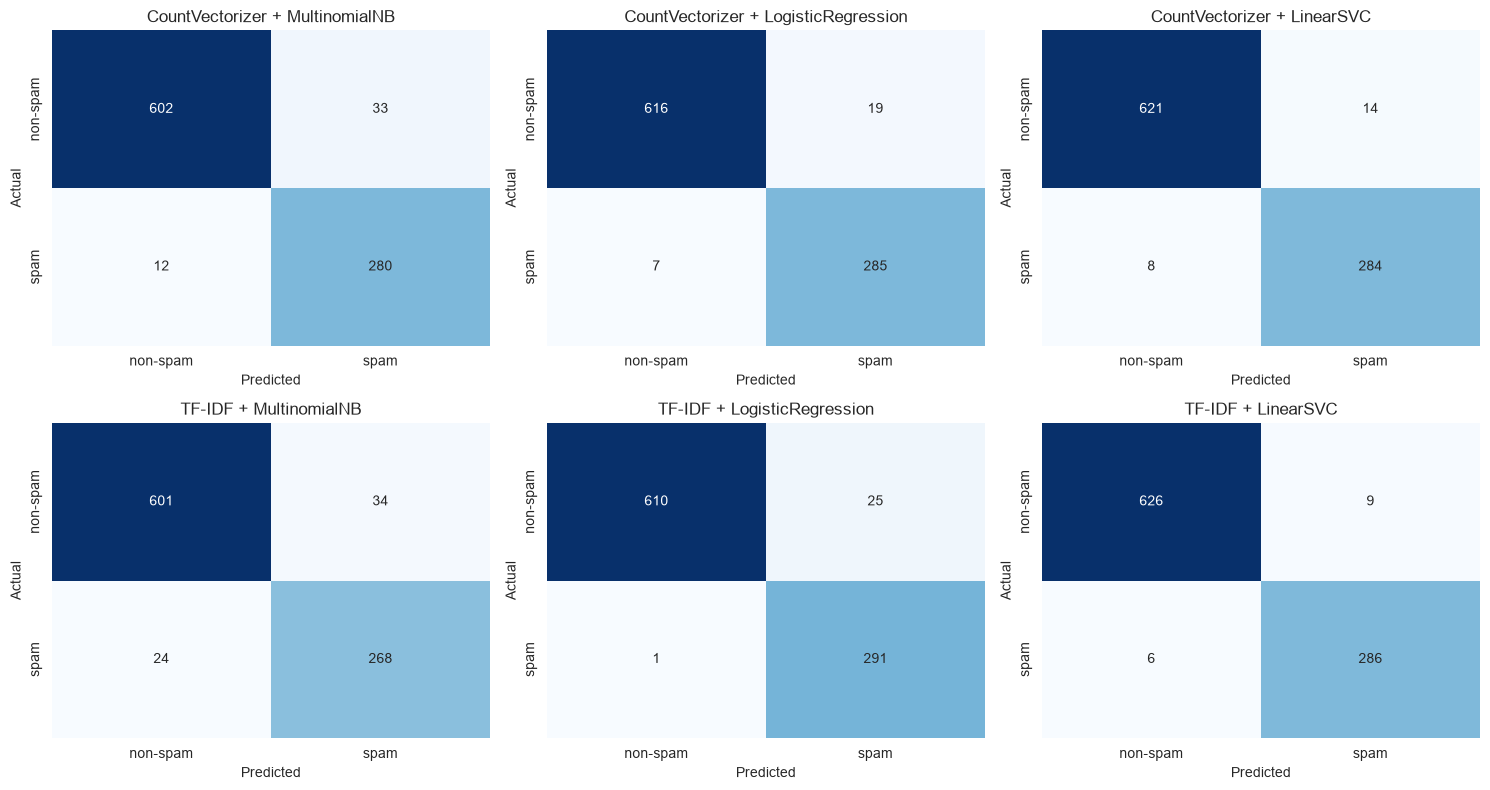

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, vec_name in enumerate(vec_names):
    for c, model_name in enumerate(model_names):
        sns.heatmap(conf_mats[(vec_name, model_name)], annot=True, fmt="d", cmap="Blues",
                    xticklabels=["non-spam", "spam"], yticklabels=["non-spam", "spam"],
                    ax=axes[r, c], cbar=False)
        axes[r, c].set_title(f"{vec_name} + {model_name}")
        axes[r, c].set_xlabel("Predicted")
        axes[r, c].set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 13. Classification report for the best configuration

In [19]:
best = res.sort_values("F1", ascending=False).iloc[0]
print(f"Best by F1: {best['Vectorizer']} + {best['Model']}  (F1 = {best['F1']:.4f})\n")
print(reports[(best["Vectorizer"], best["Model"])])

Best by F1: TF-IDF + LinearSVC  (F1 = 0.9744)

              precision    recall  f1-score   support

    non-spam       0.99      0.99      0.99       635
        spam       0.97      0.98      0.97       292

    accuracy                           0.98       927
   macro avg       0.98      0.98      0.98       927
weighted avg       0.98      0.98      0.98       927



## 14. Robustness check: 5-fold cross-validation
A single 80/20 split can be lucky or unlucky. Full pipelines (vectorizer + model) are cross-validated so the vectorizer is refit inside each fold with no leakage.

In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
texts_arr = np.array(texts, dtype=object)
cv_rows = []

for vec_name in vec_names:
    for model_name in model_names:
        pipe = Pipeline([("vec", make_vectorizer(vec_name)), ("clf", make_model(model_name))])
        scores = cross_validate(pipe, texts_arr, y, cv=skf,
                                scoring=["accuracy", "precision", "recall", "f1"])
        cv_rows.append({
            "Vectorizer": vec_name, "Model": model_name,
            "F1 mean": scores["test_f1"].mean(), "F1 std": scores["test_f1"].std(),
            "Recall mean": scores["test_recall"].mean(),
            "Precision mean": scores["test_precision"].mean(),
            "Accuracy mean": scores["test_accuracy"].mean(),
        })

pd.DataFrame(cv_rows).sort_values("F1 mean", ascending=False).round(4).reset_index(drop=True)

,Vectorizer,Model,F1 mean,F1 std,Recall mean,Precision mean,Accuracy mean
0,TF-IDF,LinearSVC,0.9750,0.0052,0.9884,0.9621,0.9840
1,TF-IDF,LogisticRegression,0.9530,0.0053,0.9918,0.9172,0.9691
2,CountVectorizer,LogisticRegression,0.9479,0.0040,0.9644,0.9321,0.9665
3,CountVectorizer,LinearSVC,0.9441,0.0036,0.9603,0.9287,0.9642
4,CountVectorizer,MultinomialNB,0.9160,0.0073,0.9548,0.8808,0.9447
5,TF-IDF,MultinomialNB,0.8963,0.0088,0.9261,0.8687,0.9324


## 15. Most spam-indicative words (Logistic Regression)

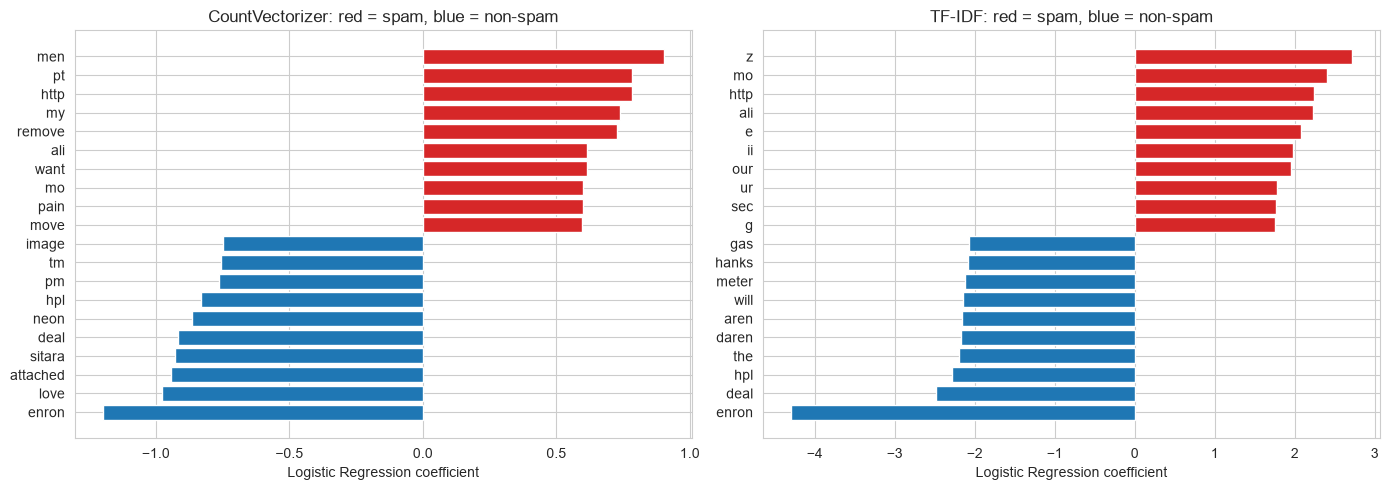

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vec_name in zip(axes, vec_names):
    Xtr, _ = features[vec_name]
    lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr, y_train)
    words = np.array(vectorizers[vec_name].get_feature_names_out())
    order = np.argsort(lr.coef_[0])
    top = np.concatenate([order[:10], order[-10:]])
    ax.barh(words[top], lr.coef_[0][top], color=["tab:blue"] * 10 + ["tab:red"] * 10)
    ax.set_title(f"{vec_name}: red = spam, blue = non-spam")
    ax.set_xlabel("Logistic Regression coefficient")

plt.tight_layout()
plt.show()

## 16. Predict on new emails
New text is vectorized with the fitted vocabulary, so any word outside the 3000-word vocabulary is ignored.

In [22]:
best_vec = vectorizers[best["Vectorizer"]]
best_model = make_model(best["Model"]).fit(features[best["Vectorizer"]][0], y_train)

samples = [
    "congratulations you have won a free prize click now to claim your cash today",
    "hi team please find attached the agenda for tomorrow s project meeting",
    "urgent your account is suspended verify your password immediately",
    "can you send me the lecture notes from yesterday s class thanks",
]
pred = best_model.predict(best_vec.transform(samples))
for s, p in zip(samples, pred):
    print(("SPAM    " if p == 1 else "NON-SPAM"), "|", s[:80])

NON-SPAM | congratulations you have won a free prize click now to claim your cash today
NON-SPAM | hi team please find attached the agenda for tomorrow s project meeting
NON-SPAM | urgent your account is suspended verify your password immediately
NON-SPAM | can you send me the lecture notes from yesterday s class thanks


## 17. Conclusions

Fill in with your own numbers from the tables above:

1. **Class distribution:** state the spam vs non-spam percentages and why F1 and recall matter more than accuracy.
2. **Number of features:** both vectorizers produce the same number of features (the 3000-word vocabulary), because the vocabulary is fixed by the dataset and both use identical token settings. The difference is in the values: raw counts vs. IDF-weighted, length-normalised scores (sparsity is identical too).
3. **Predictive performance:** state which representation gave higher F1 / recall for each model, and whether the cross-validation results agree with the single split. TF-IDF often helps linear models such as Logistic Regression and LinearSVC, while MultinomialNB frequently works well on raw counts.
4. **Training and prediction time:** TF-IDF adds a small vectorization overhead (computing IDF and normalising). Model training and prediction times are usually close, and prediction times are tiny, so treat small differences as noise.
5. **Limitations:** the vocabulary is capped at the 3000 most common words, word order is lost (no n-grams), and the pseudo-text was rebuilt from counts, so the vectorization timings reflect this synthetic text rather than real raw emails.
6. **Recommendation:** name the best vectorizer + model combination and justify it with F1, recall and time.